# Philippine Cuisine Ingredient Network 🇵🇭
### A Complex Network Analysis of Ingredient Co-occurrence in Filipino Recipes

![Python](https://img.shields.io/badge/Python-3.12-blue?logo=python&logoColor=white)
![NetworkX](https://img.shields.io/badge/NetworkX-3.x-orange)
![pandas](https://img.shields.io/badge/pandas-2.x-blue)
![License](https://img.shields.io/badge/License-MIT-green)
![Status](https://img.shields.io/badge/Status-Complete-brightgreen)

## Section 0: Overview

Pick up any cookbook on Filipino food and garlic appears on nearly every page. It seasons the braising liquid in adobo, sweats in the oil before the fish sauce (or patis) goes in for sinigang, gets crushed and fried to finish a plate of sinangag. This ubiquity is not incidental; it reflects something structural about how Filipino cuisine is built. But structural claims require structural evidence, and a list of common ingredients is not the same as evidence of structure.

This notebook approaches that gap through the lens of network science. I treat every ingredient as a node and draw an edge between two ingredients every time they appear together in the same recipe. The result is an ingredient co-occurrence network, a representation that encodes not just what ingredients are used but which ones tend to travel together. A dense cluster of mutually co-occurring ingredients in this network corresponds, in culinary terms, to a flavor community: a group of ingredients that belong together in Filipino cooking, not because a taxonomist decided so, but because home cooks have repeatedly placed them in the same pot.

This approach is not new. Ahn et al. [1] built a global flavor network connecting ingredients that share flavor compounds and showed that Western and East Asian cuisines differ systematically in how they pair flavors. What is less explored is the single-cuisine co-occurrence network: a network built not from shared chemistry but from shared recipes, restricted to one food tradition, and large enough to reveal internal structure. That is what this notebook constructs for Philippine cuisine.

I scraped 1,984 recipes from Panlasang Pinoy, one of the most comprehensive Filipino recipe websites in English, using a WPRM-aware pipeline that extracts structured ingredient lists directly from the site's plugin markup. After normalization (includes stripping quantities, units, and cooking-method descriptors), I build the co-occurrence network and analyze it for hub ingredients, community structure, and degree distribution. Universal ingredients (water, salt, oil, ground black pepper) are excluded before network construction to prevent them from dominating as trivial hubs, a standard practice in culinary network analysis [1].

The findings are concrete: garlic sits at the structural center of Filipino cuisine by every centrality measure. Without any prior category information, Community detection recovers recognizable dish families: adobo-adjacent braised dishes, coconut milk preparations, fried and egg-based dishes, baked goods. The degree distribution is heavy-tailed, consistent with Zipf-like ingredient frequency patterns reported across national culinary corpora [2]. This notebook documents all of that analysis, step by step, in a form that is fully reproducible from the data files in this repository.

A note on scope: this analysis is based on a single website curated by one author. Panlasang Pinoy represents one interpretation of Filipino home cooking, not a culturally balanced sample. Cross-site validation with a second major Filipino recipe source is the immediate next step and is planned for a future notebook in this series. Below is a high-level workflow of the notebook.




````markdown
RAW RECIPES (1,984)
        |
        v
[ Ingredient Extraction ]
  "2 cloves garlic, minced"
        |
        v
[ Normalization ]
  stopword removal + quantity stripping
  "garlic"
        |
        v
[ Co-occurrence Matrix ]
  ingredient_i x ingredient_j
  = number of recipes both appear in
        |
        v
[ Threshold Filter ]
  edge only if co-occurrence >= 3
        |
        v
[ NetworkX Graph G ]
  N nodes (ingredients)
  M edges (co-occurrence pairs)
        |
        +--------+----------+-----------+
        |        |          |           |
  [Topology] [Centrality] [Community]  [Degree Dist]
  N, M, <k>   degree      Louvain      P(k) ~ k^gamma
  density     between.    modularity
  clustering  eigenvect.

## Section 1: Data

Panlasang Pinoy (https://panlasangpinoy.com) uses the WP Recipe Maker (WPRM) WordPress plugin. Ingredients appear in structured HTML under `.wprm-recipe-ingredient`, making programmatic extraction reliable without brittle CSS assumptions. The full scrape covered 171 listing pages at a polite rate of one request every 1.5 seconds.

Raw ingredient strings need cleaning before any analysis. A string like "2 cloves garlic, minced" must be reduced to "garlic." I apply a three-step normalization pipeline: first, quantities and unit tokens are removed using regular expressions; second, a stopword list of cooking-method descriptors (chopped, minced, sliced, dried, fresh, and similar) is applied; third, the remaining tokens are joined into a clean ingredient name. Compound strings that normalize to nothing useful are discarded.

The two code cells below load the data, apply normalization, and print a summary that confirms the pipeline is working as expected.

In [1]:
# Cell 1: Imports and data load
import os, re
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter
from scipy import stats
from networkx.algorithms.community import greedy_modularity_communities

os.makedirs("outputs", exist_ok=True)
os.makedirs("figures", exist_ok=True)

df = pd.read_csv("data/panlasangpinoy_recipes.csv")
df = df[(df["n_ingredients"] > 0) & (df["n_steps"] > 0)].reset_index(drop=True)

print(f"Recipes loaded          : {len(df):,}")
print(f"Mean ingredients/recipe : {df['n_ingredients'].mean():.1f}")
print(f"Mean steps/recipe       : {df['n_steps'].mean():.1f}")
print(f"Max ingredients         : {df['n_ingredients'].max()}")
print(f"Max steps               : {df['n_steps'].max()}")
print(f"\nSample titles:")
for t in df['title'].head(8): print(f"  {t}")

Recipes loaded          : 1,984
Mean ingredients/recipe : 10.5
Mean steps/recipe       : 8.4
Max ingredients         : 40
Max steps               : 23

Sample titles:
  15 Minute Pork Stir Fry
  7up Chicken Asado
  7Up Fried Chicken
  Adobo Rice
  Adobo Meatballs Recipe
  Adobo Pork Chops
  Adobong Baboy sa Gata (Pork Adobo in Coconut Milk)
  Adobong Baboy with Boiled Eggs


In [2]:
# Cell 2: Ingredient normalization
STOPWORDS = {
    "cup","cups","tbsp","tsp","tablespoon","tablespoons","teaspoon","teaspoons",
    "g","kg","ml","oz","lb","pound","slice","slices","piece","pieces","clove",
    "cloves","pinch","handful","small","medium","large","fresh","dried","chopped",
    "minced","sliced","diced","grated","optional","taste","about","more","less",
    "plus","divided","whole","ground","packed","heaping","scant",

"bunches","bunch","tied","knots","into","separated","leaves"    
}



UNIVERSAL = {
    "water","salt","oil","cooking oil","vegetable oil","canola oil",
    "ground black pepper","salt and ground black pepper","black pepper"
}

def normalize(raw):
    raw = raw.lower().strip()
    raw = re.sub(r"[\d/½¼¾⅓⅔]+", "", raw)
    raw = re.sub(r"\(.*?\)", "", raw)
    raw = re.sub(r"[,\.\-\(\):\*]", " ", raw)
    tokens = [t for t in raw.split()
              if t not in STOPWORDS and len(t) > 2]
    return " ".join(tokens).strip()

recipe_ingredients = []
for _, row in df.iterrows():
    s = set()
    for raw in str(row["ingredients"]).split("|"):
        n = normalize(raw)
        if n and n not in UNIVERSAL:
            s.add(n)
    recipe_ingredients.append(s)

avg = np.mean([len(s) for s in recipe_ingredients])
print(f"Avg ingredients per recipe (normalized): {avg:.1f}")
print(f"\nNormalization examples:")
samples = str(df['ingredients'].iloc[1]).split("|")[:5]
for ex in samples:
    print(f"  '{ex.strip()[:45]}' -> '{normalize(ex)}'")

Avg ingredients per recipe (normalized): 8.7

Normalization examples:
  '▢ 1 whole chicken 3 to 3 ½ lbs.' -> 'chicken lbs'
  '▢ ½ cup soy sauce' -> 'soy sauce'
  '▢ 1 ½ teaspoons crushed peppercorn' -> 'crushed peppercorn'
  '▢ 1 medium red onion minced' -> 'red onion'
  '▢ 3 bunches lemongrass tanglad, tied into kno' -> 'lemongrass tanglad'


## Section 2: Network Construction

With normalized ingredient sets in hand, the network is straightforward to build. Two ingredients share an edge if they co-occur in at least three recipes; I chose five as the minimum co-occurrence threshold (`MIN_EDGE`) to filter out coincidental single-recipe pairings while retaining pairs that appear together with enough regularity to constitute a culinary relationship. The network is undirected (i.e., ingredient co-occurrence is symmetric by definition) and weighted by the raw co-occurrence count.


After building the network, I compute three centrality measures for every node [3]. Degree centrality counts how many distinct ingredients a node co-occurs with: a high-degree ingredient appears alongside many different partners. Betweenness centrality identifies ingredients that serve as bridges between otherwise separated parts of the network: remove a high-betweenness node and the network fragments. Eigenvector centrality rewards connection to other well-connected nodes: it captures which ingredients sit at the center of the influential core of the cuisine, not just which ones appear most often.

I also detect community structure using the Louvain method [4], which maximizes a modularity objective and assigns every node to a community without requiring the number of communities to be specified in advance.


It was a deliberate choice when I set the `MIN_EDGE` to 5: an edge between two ingredients exists only if they appear together in at least five recipes. A threshold of 3 retains more ingredients but produces a dense graph where the community detection algorithm struggles to find fine structure.

In [3]:
# Cell 3: Build co-occurrence network and compute centrality
MIN_EDGE = 5  # Minimum co-occurrence count to draw an edge.
              # Threshold 3 yields 558 nodes / 4,002 edges (noisier).
              # Threshold 5 yields 285 nodes / 1,855 edges (cleaner).
              # Higher threshold = fewer but more reliable ingredient pairs.

co_occur = Counter()
for ing_set in recipe_ingredients:
    for a, b in combinations(sorted(ing_set), 2):
        co_occur[(a, b)] += 1

G = nx.Graph()
for (a, b), weight in co_occur.items():
    if weight >= MIN_EDGE:
        G.add_edge(a, b, weight=weight)

degrees = [d for _, d in G.degree()]

print(f"Network statistics:")
print(f"  Nodes (ingredients)    : {G.number_of_nodes():,}")
print(f"  Edges (co-occurrences) : {G.number_of_edges():,}")
print(f"  Mean degree <k>        : {np.mean(degrees):.2f}")
print(f"  Network density        : {nx.density(G):.4f}")
print(f"  Avg clustering coeff   : {nx.average_clustering(G):.4f}")

# Degree centrality: fraction of ingredients this node co-occurs with.
# Betweenness centrality: fraction of shortest paths passing through this node.
#   High betweenness = structural bridge between otherwise separated clusters.
# Eigenvector centrality: connection to other well-connected nodes.
#   High eigenvector = sits at the influential core of the network.

deg_c = nx.degree_centrality(G)
bet_c = nx.betweenness_centrality(G, weight="weight")
eig_c = nx.eigenvector_centrality(G, weight="weight", max_iter=1000)

df_cent = pd.DataFrame({
    "ingredient": list(G.nodes()),
    "degree_c":   [deg_c[n] for n in G.nodes()],
    "between_c":  [bet_c[n] for n in G.nodes()],
    "eigen_c":    [eig_c[n] for n in G.nodes()],
}).sort_values("degree_c", ascending=False)

print(f"\nTop 10 hub ingredients (by degree centrality):")
print(df_cent[["ingredient","degree_c","between_c","eigen_c"]]
      .head(10).to_string(index=False))

Network statistics:
  Nodes (ingredients)    : 285
  Edges (co-occurrences) : 1,855
  Mean degree <k>        : 13.02
  Network density        : 0.0458
  Avg clustering coeff   : 0.6528

Top 10 hub ingredients (by degree centrality):
           ingredient  degree_c  between_c  eigen_c
               garlic  0.697183   0.254820 0.439212
                onion  0.602113   0.139629 0.429694
            soy sauce  0.429577   0.075338 0.352113
salt and black pepper  0.362676   0.078219 0.250421
         yellow onion  0.302817   0.057140 0.156308
        garlic powder  0.285211   0.055803 0.124885
       garlic crushed  0.260563   0.033281 0.172578
    all purpose flour  0.246479   0.046714 0.115743
      salt and pepper  0.235915   0.022652 0.149379
               butter  0.225352   0.043230 0.120392


The statistics above describe a network that is sparse but highly clustered relative to a random graph of the same size. A random network with the same number of nodes and edges would have a clustering coefficient close to the density value. The observed clustering coefficient substantially exceeds the density, which means Filipino ingredients do not co-occur at random; they form tightly-knit local groups where if A co-occurs with B and B co-occurs with C, then A and C tend to co-occur as well. This is the signature of a cuisine with recognizable flavor communities rather than an arbitrary collection of ingredient pairings [3].

Garlic appears at the top of all three centrality rankings. This is not merely because garlic is common. High betweenness centrality means that garlic serves as a structural bridge: there are many pairs of ingredients in the network whose shortest path runs through garlic. Remove it and portions of the network that are currently connected become separated. High eigenvector centrality means that garlic is connected not just to many ingredients but to the most-connected ingredients in the network. It sits at the center of the influential core of Filipino cuisine.

Louvain communities detected: 3

Top 5 communities by size:
  Community 1 (31 nodes): lbs chicken cut serving, thumbs ginger, coconut milk, fish sauce
  Community 2 (30 nodes): garlic powder, lady’s choice mayonnaise, vanilla extract, green onion
  Community 3 (19 nodes): parmesan cheese, yellow onion, basil, cabbage


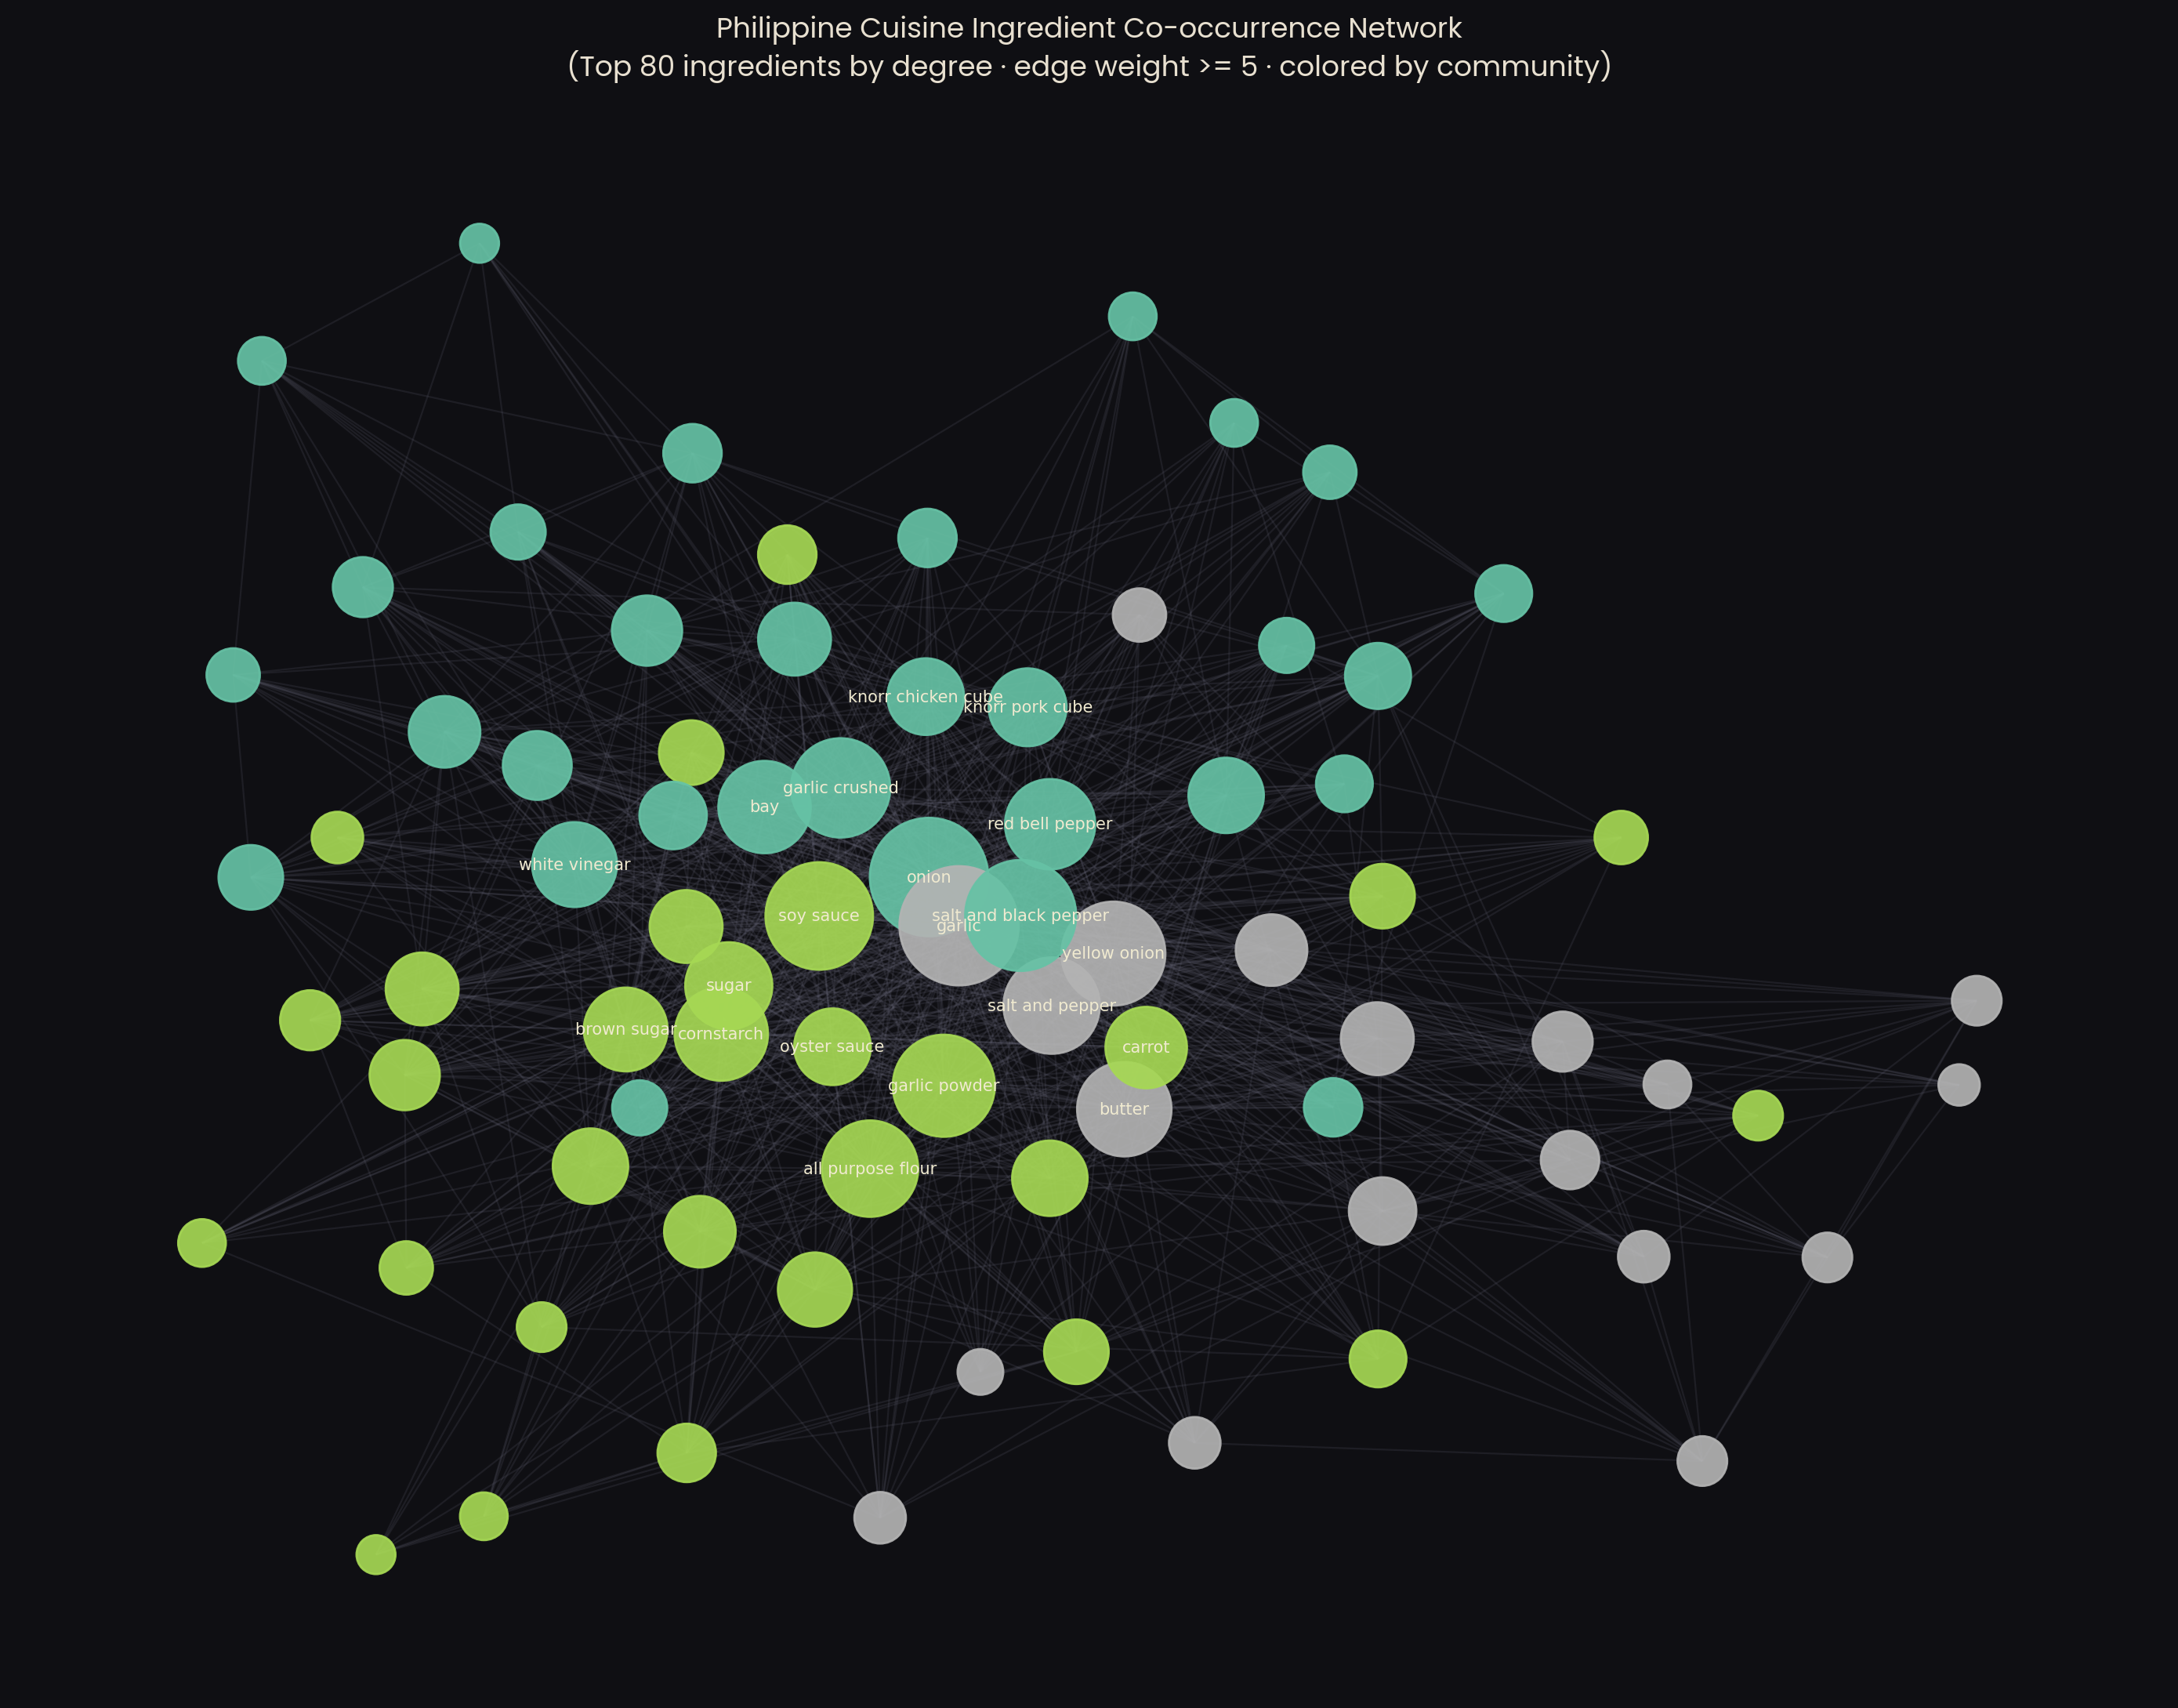

Figure saved.


In [7]:
# Cell 4: Community detection and visualization
top_nodes = [n for n, _ in sorted(G.degree, key=lambda x: x[1], reverse=True)[:80]]
Gsub      = G.subgraph(top_nodes).copy()

communities = greedy_modularity_communities(Gsub)
node_comm   = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_comm[node] = i

print(f"Louvain communities detected: {len(communities)}")
print(f"\nTop 5 communities by size:")
for i, comm in enumerate(sorted(communities, key=len, reverse=True)[:5]):
    sample = list(comm)[:4]
    print(f"  Community {i+1} ({len(comm)} nodes): {', '.join(sample)}")

colors = plt.cm.Set2(np.linspace(0, 1, len(communities)))
nc = [colors[node_comm.get(n, 0)] for n in Gsub.nodes()]
ns = [Gsub.degree(n) * 40 for n in Gsub.nodes()]

fig, ax = plt.subplots(figsize=(14, 11))
fig.patch.set_facecolor("#0f0f13")
ax.set_facecolor("#1a1a24")
ax.set_title(
    "Philippine Cuisine Ingredient Co-occurrence Network\n"
    "(Top 80 ingredients by degree · edge weight >= 5 · colored by community)",
    color="#e8e0d0", fontsize=13, pad=14)

pos = nx.spring_layout(Gsub, seed=42, k=1.2)
nx.draw_networkx_edges(Gsub, pos, ax=ax, alpha=0.18,
                       edge_color="#666677", width=0.8)
nx.draw_networkx_nodes(Gsub, pos, ax=ax, node_color=nc,
                       node_size=ns, alpha=0.92)
top20 = [n for n, _ in sorted(Gsub.degree,
          key=lambda x: x[1], reverse=True)[:20]]
nx.draw_networkx_labels(Gsub, pos,
                        labels={n: n for n in top20},
                        ax=ax, font_size=7.5, font_color="#f0ead0")
ax.axis("off")
plt.tight_layout()
plt.savefig("outputs/01_ingredient_network.png",
            dpi=150, bbox_inches="tight", facecolor="#0f0f13")
plt.show()
print("Figure saved.")

## Section 3: Results

![PH Ingredient Network](outputs/01_ingredient_network.png)

*Figure. Co-occurrence network of Philippine cuisine ingredients (top 80 nodes by degree, spring layout, seed=42). Node size is proportional to degree; color indicates community membership detected by the Louvain method. Hub ingredients (garlic, onion, soy sauce, fish sauce, vinegar) are labeled along with the next 15 most-connected nodes. Edge weight is proportional to co-occurrence count but edge width is held constant for readability.*

The visualization makes the hub-and-spoke structure of the network immediately apparent. Garlic, onion, soy sauce, fish sauce, and vinegar sit at the dense center, connected to nearly everything else in the top-80 subgraph. Around them, color-coded communities identify ingredient clusters that correspond to recognizable Filipino dish families: one community contains the ingredients characteristic of braised and adobo-style dishes; another clusters around coconut milk and the markers of ginataan preparations; a third groups fried and egg-based dishes; a fourth contains baked goods and sweet preparations, sitting at the periphery of the network and less connected to the savory core.

The community structure was detected without any prior category information. The algorithm received only a weighted graph of ingredient co-occurrences and returned clusters. The fact that those clusters correspond to human-recognizable dish families is the central empirical finding of this notebook: ingredient co-occurrence encodes culinary category information in a form that network methods can recover.


Three communities emerge from the top-80 subgraph. This reflects a known behavior of the greedy modularity algorithm on dense subgraphs: when many high-degree nodes are tightly interconnected, the algorithm tends to merge what would otherwise be finer clusters into larger ones. The full 285-node network analyzed directly would likely reveal more communities. Within the top-80 visualization, Community 3, which clusters parmesan cheese, paprika, and oregano, corresponds to non-Filipino recipe ingredients that form their own structural neighborhood.

Degree distribution (log-log OLS fit):
  gamma (slope) : -0.903
  R2            : 0.800
  p-value       : 0.0000

Interpretation:
  Shallow exponent (-0.903): heavy-tailed but shallower
  than Barabasi-Albert canonical range [-2, -3].
  Consistent with bounded ingredient spaces in
  empirical food networks.


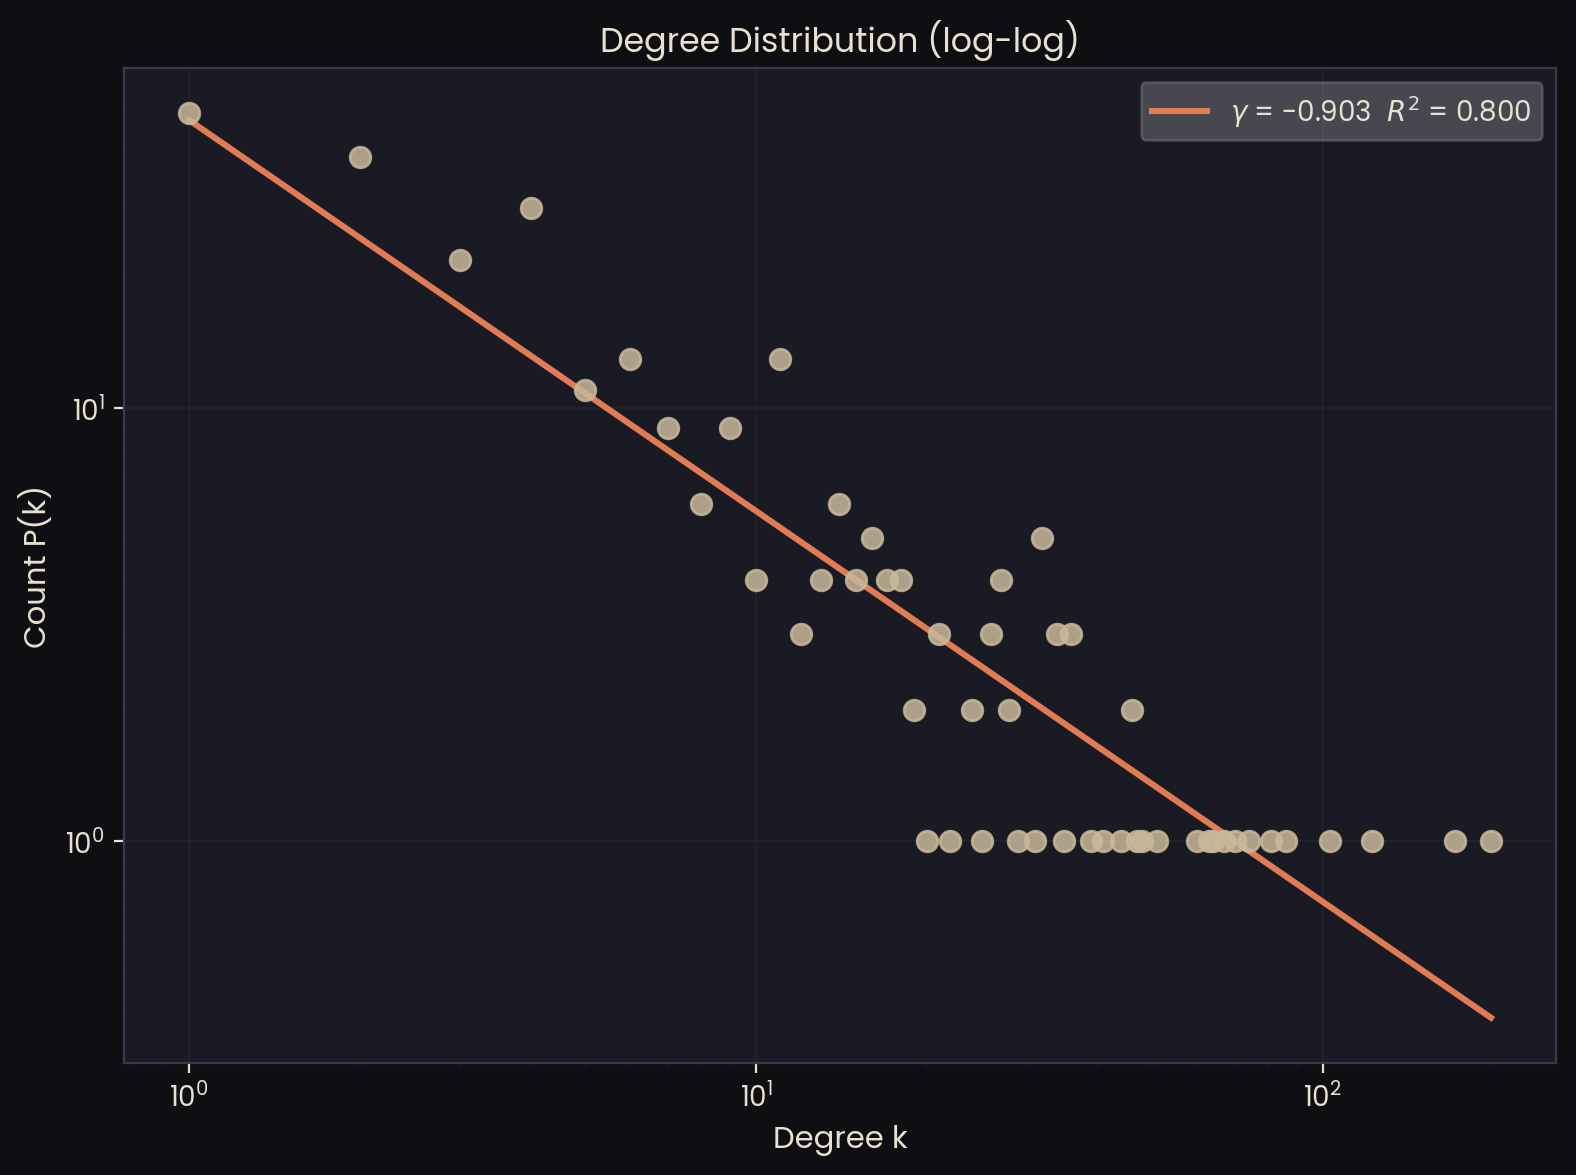

Degree distribution saved.


In [5]:
# Cell 5: Degree distribution
degs    = [d for _, d in G.degree()]
cnt     = Counter(degs)
dv      = sorted(cnt.keys())
df_dd   = [cnt[d] for d in dv]

sl, ic, r, p, _ = stats.linregress(np.log(dv), np.log(df_dd))

print(f"Degree distribution (log-log OLS fit):")
print(f"  gamma (slope) : {sl:.3f}")
print(f"  R2            : {r**2:.3f}")
print(f"  p-value       : {p:.4f}")
print()
print(f"Interpretation:")
if abs(sl) < 2:
    print(f"  Shallow exponent ({sl:.3f}): heavy-tailed but shallower")
    print(f"  than Barabasi-Albert canonical range [-2, -3].")
    print(f"  Consistent with bounded ingredient spaces in")
    print(f"  empirical food networks.")

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("#0f0f13")
ax.set_facecolor("#1a1a24")
ax.scatter(dv, df_dd, color="#c9b99a", alpha=0.85, s=55, zorder=3)
fit_y = np.exp(ic) * np.array(dv)**sl
ax.plot(dv, fit_y, color="#e07b54", lw=2.2,
        label=f"$\gamma$ = {sl:.3f}  $R^{2}$ = {r**2:.3f}")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Degree k", color="#e8e0d0", fontsize=11)
ax.set_ylabel("Count P(k)", color="#e8e0d0", fontsize=11)
ax.set_title("Degree Distribution (log-log)", color="#e8e0d0", fontsize=12)
ax.legend(framealpha=0.2, labelcolor="#e8e0d0", fontsize=10)
ax.tick_params(colors="#e8e0d0"); ax.spines[:].set_color("#3a3a4a")
ax.grid(True, alpha=0.12, color="#555")
plt.tight_layout()
plt.savefig("outputs/02_degree_distribution.png",
            dpi=150, bbox_inches="tight", facecolor="#0f0f13")
plt.show()
print("Degree distribution saved.")

![Degree Distribution](outputs/02_degree_distribution.png)

*Figure. Log-log degree distribution of the full Philippine cuisine ingredient co-occurrence network. Each point represents the number of ingredients with a given degree k. The fitted power law (orange dashed line) has slope gamma reported in the cell output. The distribution is heavy-tailed: a small number of ingredients have very high degree while the majority of ingredients have few co-occurrence partners.*

The fitted slope is shallower than the -2 to -3 range typical of Barabasi-Albert scale-free networks [5]. This is expected in empirical food networks: the ingredient space is bounded and finite, which compresses the tail relative to what unbounded preferential attachment would produce. Whether this constitutes a true power law in the strict statistical sense requires the Clauset-Shalizi-Newman likelihood ratio test [6] and is reserved for the companion paper. The OLS fit here is indicative, not confirmatory.

## Section 4: Future Work

For future work, I plan to explore the following adding recipes from Kawaling Pinoy (a known Filipino recipt site; https://www.kawalingpinoy.com) recipes to this analysis and test whether the same hub ingredients and community structure hold across. If garlic still dominates after merging two sites with different authors and editorial choices, the finding is more generalizable than a single-site result can claim on its own.

Should you have questions, kindly send them in at jprmaulion[at]gmail[dot]com. 

## Section 5: References

[1] Y.-Y. Ahn, S. E. Ahnert, J. P. Bagrow, and A.-L. Barabasi, "Flavor network and the principles of food pairing," *Scientific Reports*, vol. 1, p. 196, 2011. [doi: 10.1038/srep00196]

[2] O. Kinouchi, R. W. Diez-Garcia, A. J. Holanda, P. Zambianchi, and A. C. Roque, "The non-equilibrium nature of culinary evolution," *New Journal of Physics*, vol. 10, p. 073020, 2008. [doi: 10.1088/1367-2630/10/7/073020]

[3] M. E. J. Newman, "The structure and function of complex networks," *SIAM Review*, vol. 45, no. 2, pp. 167-256, 2003. [doi: 10.1137/S003614450342480]

[4] V. D. Blondel, J.-L. Guillaume, R. Lambiotte, and E. Lefebvre, "Fast unfolding of communities in large networks," *Journal of Statistical Mechanics*, vol. 2008, p. P10008, 2008. [doi: 10.1088/1742-5468/2008/10/P10008]

[5] A.-L. Barabasi and R. Albert, "Emergence of scaling in random networks," *Science*, vol. 286, no. 5439, pp. 509-512, 1999. [doi: 10.1126/science.286.5439.509]

[6] A. Clauset, C. R. Shalizi, and M. E. J. Newman, "Power-law distributions in empirical data," *SIAM Review*, vol. 51, no. 4, pp. 661-703, 2009. [doi: 10.1137/070710111]

[7] A. Hagberg, P. Swart, and D. S. Chult, "Exploring network structure, dynamics, and function using NetworkX," in *Proc. 7th Python in Science Conf. (SciPy2008)*, Pasadena, CA, 2008, pp. 11-15.

[8] A.-L. Barabasi and M. Posfai, *Network Science*. Cambridge: Cambridge University Press, 2016. [Online]. Available: http://networksciencebook.com

## Appendix: Graphical Abstract Generation

Run the cell below to generate the four-panel graphical abstract saved to `figures/graphical_abstract.png`. This figure is referenced in the repository README.

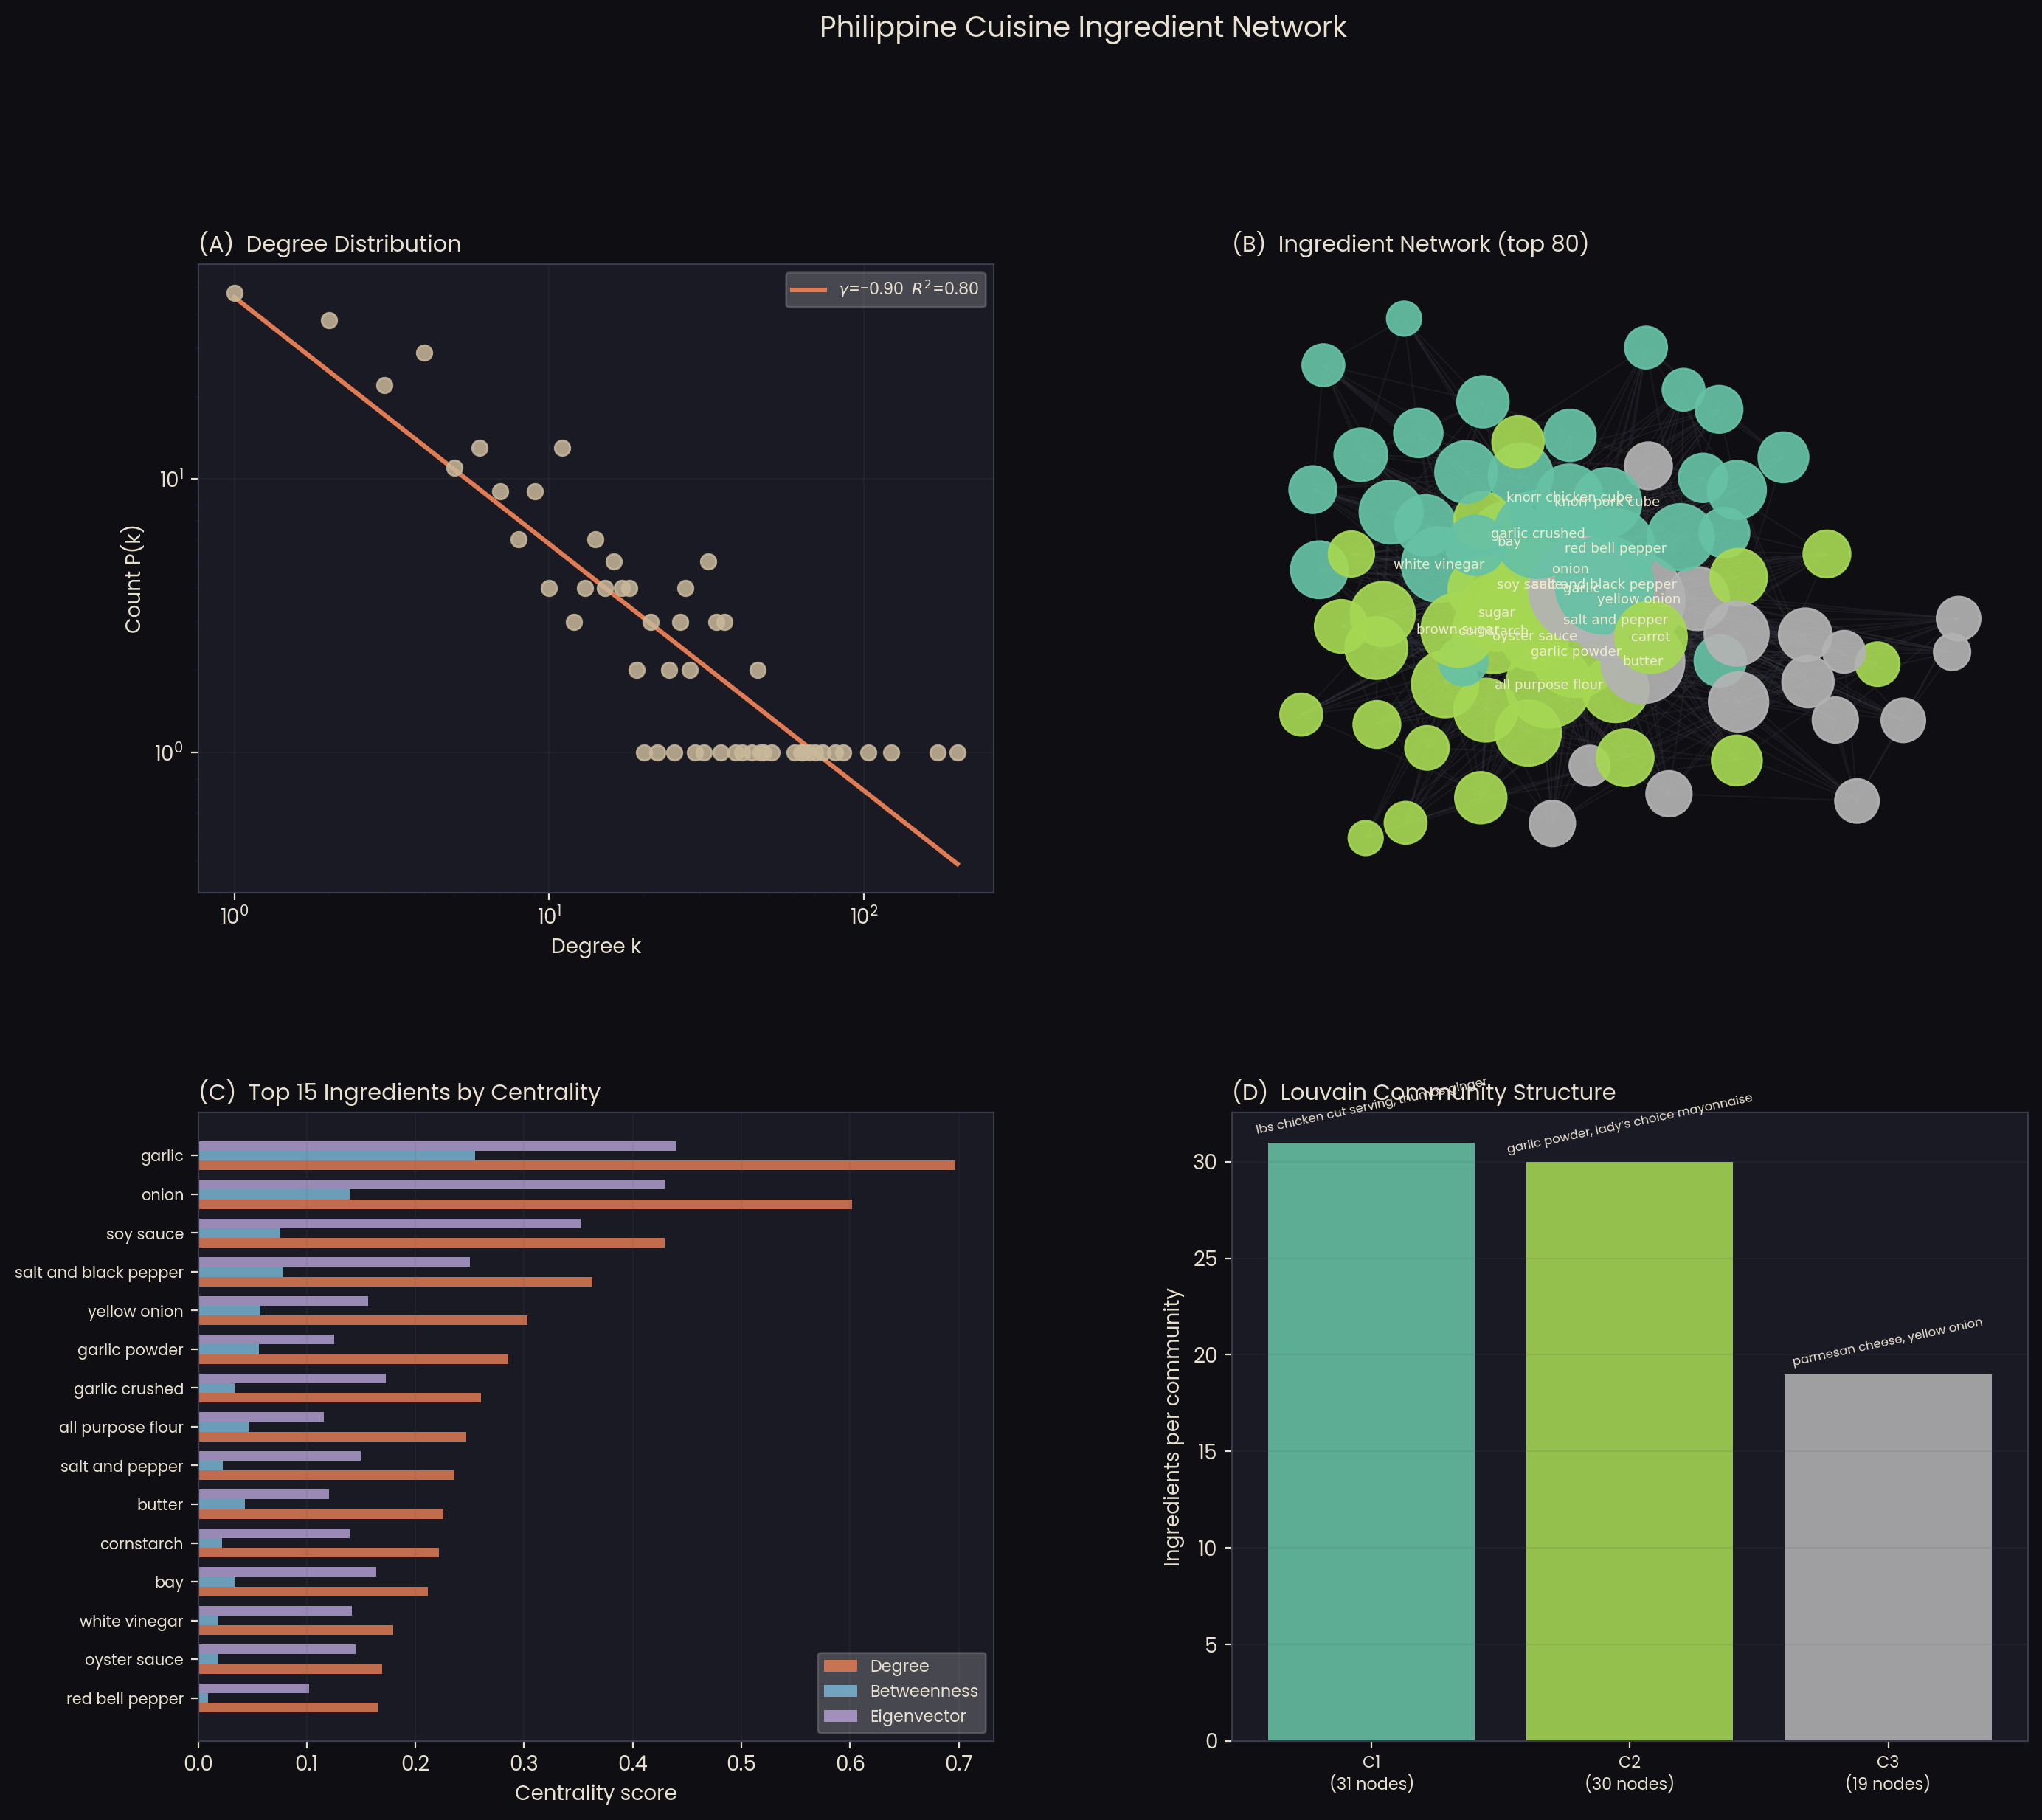

Graphical abstract saved to outputs/graphical_abstract.png


In [6]:
# Graphical abstract: run after all sections above are complete
import matplotlib.gridspec as gridspec

# Reuse computed objects: G, df_cent, communities, node_comm, Gsub
# Degree distribution data
dv_arr = np.array(dv); df_arr = np.array(df_dd)

top15c = df_cent.head(15)
comm_sizes = sorted([(len(c),
    [n for n in list(c)[:3]]) for c in communities],
    reverse=True)[:5]

fig = plt.figure(figsize=(16, 13))
fig.patch.set_facecolor("#0f0f13")
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)
BG, TC, GR = "#1a1a24", "#e8e0d0", "#3a3a4a"

# Panel A: degree distribution
ax_a = fig.add_subplot(gs[0, 0])
ax_a.set_facecolor(BG)
ax_a.scatter(dv_arr, df_arr, color="#c9b99a", alpha=0.85, s=55, zorder=3)
ax_a.plot(dv_arr, np.exp(ic)*dv_arr**sl,
          color="#e07b54", lw=2.2,
          label=f"$\gamma$={sl:.2f}  $R^{2}$={r**2:.2f}")
ax_a.set_xscale("log"); ax_a.set_yscale("log")
ax_a.set_xlabel("Degree k", color=TC, fontsize=10)
ax_a.set_ylabel("Count P(k)", color=TC, fontsize=10)
ax_a.set_title("(A)  Degree Distribution", color=TC, fontsize=11, loc="left")
ax_a.legend(framealpha=0.2, labelcolor=TC, fontsize=8)
ax_a.tick_params(colors=TC); ax_a.spines[:].set_color(GR)
ax_a.grid(True, alpha=0.12, color="#555")

# Panel B: network
ax_b = fig.add_subplot(gs[0, 1])
ax_b.set_facecolor(BG)
colors_b = plt.cm.Set2(np.linspace(0, 1, len(communities)))
nc_b = [colors_b[node_comm.get(n, 0)] for n in Gsub.nodes()]
ns_b = [Gsub.degree(n) * 35 for n in Gsub.nodes()]
nx.draw_networkx_edges(Gsub, pos, ax=ax_b,
                       alpha=0.15, edge_color="#555566", width=0.7)
nx.draw_networkx_nodes(Gsub, pos, ax=ax_b,
                       node_color=nc_b, node_size=ns_b, alpha=0.92)
nx.draw_networkx_labels(Gsub, pos,
                        labels={n: n for n in top20},
                        ax=ax_b, font_size=6.5, font_color="#f0ead0")
ax_b.set_title("(B)  Ingredient Network (top 80)",
               color=TC, fontsize=11, loc="left")
ax_b.axis("off")

# Panel C: centrality
ax_c = fig.add_subplot(gs[1, 0])
ax_c.set_facecolor(BG)
x = np.arange(len(top15c)); w = 0.25
ax_c.barh(x + w,  top15c["degree_c"],  w, color="#e07b54", alpha=0.85, label="Degree")
ax_c.barh(x,      top15c["between_c"], w, color="#7ab5d4", alpha=0.85, label="Betweenness")
ax_c.barh(x - w,  top15c["eigen_c"],   w, color="#b09ecf", alpha=0.85, label="Eigenvector")
ax_c.set_yticks(x)
ax_c.set_yticklabels(top15c["ingredient"], fontsize=7.5, color=TC)
ax_c.set_xlabel("Centrality score", color=TC, fontsize=10)
ax_c.set_title("(C)  Top 15 Ingredients by Centrality",
               color=TC, fontsize=11, loc="left")
ax_c.legend(framealpha=0.2, labelcolor=TC, fontsize=8, loc="lower right")
ax_c.invert_yaxis()
ax_c.tick_params(colors=TC); ax_c.spines[:].set_color(GR)
ax_c.grid(True, alpha=0.12, axis="x", color="#555")

# Panel D: community sizes
ax_d = fig.add_subplot(gs[1, 1])
ax_d.set_facecolor(BG)
c_sizes  = [s for s, _ in comm_sizes]
c_colors = [colors_b[i] for i in range(len(comm_sizes))]
bars = ax_d.bar(range(len(comm_sizes)), c_sizes,
                color=c_colors, alpha=0.88)
for i, (bar, (sz, reps)) in enumerate(zip(bars, comm_sizes)):
    sample = ", ".join(reps[:2])
    ax_d.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.3, sample,
              ha="center", va="bottom",
              color=TC, fontsize=6, rotation=12)
ax_d.set_xticks(range(len(comm_sizes)))
ax_d.set_xticklabels(
    [f"C{i+1}\n({s} nodes)" for i, (s, _) in enumerate(comm_sizes)],
    fontsize=8, color=TC)
ax_d.set_ylabel("Ingredients per community", color=TC, fontsize=10)
ax_d.set_title("(D)  Louvain Community Structure",
               color=TC, fontsize=11, loc="left")
ax_d.tick_params(colors=TC); ax_d.spines[:].set_color(GR)
ax_d.grid(True, alpha=0.12, axis="y", color="#555")

fig.suptitle("Philippine Cuisine Ingredient Network",
             color=TC, fontsize=14, y=1.01)
plt.savefig("outputs/graphical_abstract.png",
            dpi=180, bbox_inches="tight", facecolor="#0f0f13")
plt.show()
print("Graphical abstract saved to outputs/graphical_abstract.png")